Dataset: Kaggle

In [180]:
import pandas as pd

# 1. Load the Dataset


In [337]:
data = pd.read_csv(r"C:\Users\surya\Downloads\bumble_google_play_reviews.csv")
data.tail()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
178568,61bc7cdc-3085-4631-ac95-d8e42e2e0742,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Finally here!,5,54,1.0.1,2015-12-01 02:17:24,NaN,NaN,1.0.1
178569,24d07489-88ad-496a-80ce-8f137c130323,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Finally!,5,73,1.0.1,2015-12-01 02:09:05,NaN,NaN,1.0.1
178570,22a42d0d-7a12-400d-a2af-826f35d21581,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Finally, an app where women have to start the ...",4,2,1.0.1,2015-12-01 00:18:53,NaN,NaN,1.0.1
178571,2480a41f-8863-4948-9f83-7d856bd9dc78,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,At last we have Android version!,5,60,1.0.0,2015-11-30 21:27:51,NaN,NaN,1.0.0
178572,6ebb270a-3b4b-4ff5-b98c-8899dcfd40ee,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Nice and smooth.,5,51,NaN,2015-11-29 23:15:25,NaN,NaN,NaN


In [270]:
data.shape

(178573, 11)

In [183]:
data.columns

Index(['reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'appVersion'],
      dtype='str')

In [184]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 178573 entries, 0 to 178572
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   reviewId              178573 non-null  str  
 1   userName              178573 non-null  str  
 2   userImage             178573 non-null  str  
 3   content               178555 non-null  str  
 4   score                 178573 non-null  int64
 5   thumbsUpCount         178573 non-null  int64
 6   reviewCreatedVersion  146430 non-null  str  
 7   at                    178573 non-null  str  
 8   replyContent          122830 non-null  str  
 9   repliedAt             122830 non-null  str  
 10  appVersion            146430 non-null  str  
dtypes: int64(2), str(9)
memory usage: 15.0 MB


In [185]:
data.isnull().sum()

reviewId                    0
userName                    0
userImage                   0
content                    18
score                       0
thumbsUpCount               0
reviewCreatedVersion    32143
at                          0
replyContent            55743
repliedAt               55743
appVersion              32143
dtype: int64

# 2. Handle Missing Data


In [338]:
data1 = data.dropna(subset = ['content'])
data1.isnull().sum()

reviewId                    0
userName                    0
userImage                   0
content                     0
score                       0
thumbsUpCount               0
reviewCreatedVersion    32137
at                          0
replyContent            55733
repliedAt               55733
appVersion              32137
dtype: int64

# 3.Remove Duplicates and Conflicts

In [339]:
data1['content'].value_counts()

content
good                                                                                                                                                                                   2081
Good                                                                                                                                                                                   1645
nice                                                                                                                                                                                    879
Great                                                                                                                                                                                   783
Nice                                                                                                                                                                                    566
                                                    

In [340]:
data1 = data1.drop_duplicates(subset="content", keep='first')
data1 = data1.reset_index(drop=True)

print(data1.shape)

(153166, 11)


# 4.Drop Unnecessary Columns/Rows

In [341]:
data1 = data1.drop(['userName', 'userImage','reviewCreatedVersion',  'replyContent',
       'repliedAt', 'appVersion'], axis = 1)
data1.columns

Index(['reviewId', 'content', 'score', 'thumbsUpCount', 'at'], dtype='str')

# 5.Clean the Review Text

In [343]:
import re

def clean_text(text):
    
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    
    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    
    
    text = re.sub(r'\s+',' ', text).strip() #removed extra space
    
    return text

data1['content'] = data1['content'].apply(clean_text)

data1['content'].tail()

153161                                         finally here
153162                                              finally
153163    finally an app where women have to start the c...
153164                      at last we have android version
153165                                      nice and smooth
Name: content, dtype: str

In [344]:
data1['content'].tail(10)

153156    tinder was getting ridiculous the last straw w...
153157    i have the app on my ipad and the ui here is w...
153158                                        trying it out
153159    my operating system has autorotation of images...
153160                                              finally
153161                                         finally here
153162                                              finally
153163    finally an app where women have to start the c...
153164                      at last we have android version
153165                                      nice and smooth
Name: content, dtype: str

In [ ]:
!pip install spacy

In [ ]:
!pip install click


In [ ]:
!pip install --upgrade pip
!pip install --force-reinstall spacy

In [ ]:
!python -m spacy download en_core_web_sm

In [196]:
import spacy

Lemmatization for converting the words to their base form. (Running time is high)

In [345]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

data1['content'] = [
    " ".join(token.lemma_ for token in doc)
    for doc in nlp.pipe(data1['content'], batch_size=1000)
]

data1['content'].tail(10)

153156    tinder be get ridiculous the last straw be whe...
153157    I have the app on my ipad and the ui here be w...
153158                                           try it out
153159    my operating system have autorotation of image...
153160                                              finally
153161                                         finally here
153162                                              finally
153163    finally an app where woman have to start the c...
153164                      at last we have android version
153165                                      nice and smooth
Name: content, dtype: str

Remove stopwords (using NLTK or SpaCy)

In [346]:



def remove_stopwords(text):

    doc = nlp(text)

    return " ".join(
        token.text
        for token in doc
        if not token.is_stop
    )

data1['content'] = data1['content'].apply(remove_stopwords)

data1['content'].tail(10)

153156    tinder ridiculous straw decide completely kill...
153157    app ipad ui way hit bug love app concept woman...
153158                                                  try
153159    operating system autorotation image disable ga...
153160                                              finally
153161                                              finally
153162                                              finally
153163    finally app woman start conversation love conc...
153164                                      android version
153165                                          nice smooth
Name: content, dtype: str

In [348]:
data1['content'].head(3)

0                             swipe swipe s connection
1    supposedly 3 like swipe age pay premium price ...
2                                              way app
Name: content, dtype: str

Then stopword removal removed words like it, but left the isolated token s.

In [349]:
data1['content'] = data1['content'].apply(
    lambda text: ' '.join(
        word for word in text.split()
        if len(word) > 1
    )
)

data1['content'].head(3)

0                               swipe swipe connection
1    supposedly like swipe age pay premium price ri...
2                                              way app
Name: content, dtype: str

Creating a copy and saving 

In [356]:
data2 = data1.copy()

data2.to_csv(r"C:\Users\surya\Downloads\data2.csv", index=False)

In [351]:
data3 = data2.copy()
data3.to_csv(r"C:\Users\surya\Downloads\data3.csv", index=False)


# 6. Remove Very Short Reviews
Filter out reviews with extremely low text length. min-3 words 

In [352]:
data['word_count'] = data['content'].str.split().str.len()

print(data['word_count'].max())

700.0


In [353]:
data1['word_count'] = data1['content'].str.split().str.len()


In [358]:

data1 = data1[
    (data1['word_count'] >= 3) &
    (data1['word_count'] <= 100)
]


data1.shape

(129866, 6)

In [360]:
data3['word_count'] = data3['content'].str.split().str.len()

print(data3['word_count'].max())

296


Initially the maximum Word count were 700, After preprocessing it became 296. Now, by setting limit maximum word count is 99.

In [361]:
print(data1['word_count'].max())

99


# 7.Basic Feature Engineering

In [362]:
data1['char_count'] = data1['content'].apply(len)

data1['word_count'] = data1['content'].apply(lambda x: len(x.split()))

data1.columns

data1.tail()


,reviewId,content,score,thumbsUpCount,at,word_count,char_count
153155,3360a646-5e50-486b-8e53-932bdfa76c51,ve begin conversation 15 match receive zero me...,2,6,2015-12-01 23:43:00,10,67
153156,548a05c1-6fc9-40ee-86e5-05be17d4c353,tinder ridiculous straw decide completely kill...,5,10,2015-12-01 15:59:25,20,136
153157,8bb32a0c-7def-4403-a5ec-20452ed2187f,app ipad ui way hit bug love app concept woman...,5,14,2015-12-01 13:16:29,18,89
153159,90bbf335-cf16-4631-a072-09c406c7f6bd,operating system autorotation image disable ga...,2,3,2015-12-01 05:30:01,10,73
153163,22a42d0d-7a12-400d-a2af-826f35d21581,finally app woman start conversation love conc...,4,2,2015-12-01 00:18:53,15,96


# 8.Check Final Class Distribution

In [363]:
data1['score'].value_counts().sort_index()


score
1    72635
2    13997
3    10863
4    12003
5    20368
Name: count, dtype: int64

# 9.Save the Cleaned Dataset

In [364]:
data1.head()

,reviewId,content,score,thumbsUpCount,at,word_count,char_count
0,a0060cfe-9e87-4694-8268-27025b9d9141,swipe swipe connection,1,0,2026-05-23 23:36:38,3,22
1,e7bdd002-fc77-4314-a4b2-6060efe53a0d,supposedly like swipe age pay premium price ri...,1,0,2026-05-23 23:27:41,18,122
4,fdaa6093-a265-4066-9a86-7a6db0915ef4,scam fake profile use opening format include i...,1,0,2026-05-23 22:23:48,15,96
6,4521430f-ec5c-4a26-a095-bfeb85cdcc7a,message long upload app freeze constantly,1,0,2026-05-23 21:03:55,6,41
7,68abfb71-cec5-4ef7-b347-0556ed7121f8,easy use app,5,0,2026-05-23 21:00:40,3,12


In [386]:
data1.to_csv(
    r"C:\Users\surya\Downloads\review_dataset2.csv",
    index=False
)
print("Dataset exported successfully!")

Dataset exported successfully!


In [3]:
import pandas as pd

data1 = pd.read_csv(r"C:\Users\surya\Downloads\review_dataset2.csv")

data1.head()


,reviewId,content,score,thumbsUpCount,at,word_count,char_count
0,a0060cfe-9e87-4694-8268-27025b9d9141,swipe swipe connection,1,0,2026-05-23 23:36:38,3,22
1,e7bdd002-fc77-4314-a4b2-6060efe53a0d,supposedly like swipe age pay premium price ri...,1,0,2026-05-23 23:27:41,18,122
2,fdaa6093-a265-4066-9a86-7a6db0915ef4,scam fake profile use opening format include i...,1,0,2026-05-23 22:23:48,15,96
3,4521430f-ec5c-4a26-a095-bfeb85cdcc7a,message long upload app freeze constantly,1,0,2026-05-23 21:03:55,6,41
4,68abfb71-cec5-4ef7-b347-0556ed7121f8,easy use app,5,0,2026-05-23 21:00:40,3,12


# 10. Data Visulization

Barchart - Distribution of ratings

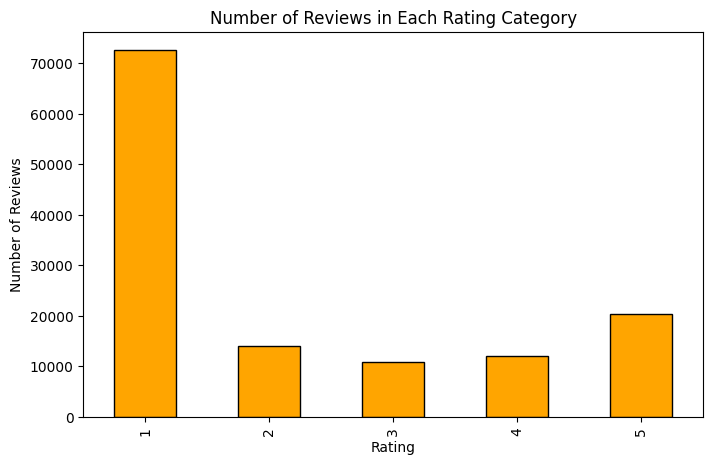

In [365]:
import matplotlib.pyplot as plt

rating_counts = data1['score'].value_counts().sort_index()

plt.figure(figsize =(8,5))

rating_counts.plot(kind = 'bar', color='orange', edgecolor = 'black')

plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.title('Number of Reviews in Each Rating Category')

plt.show()


Pie chart

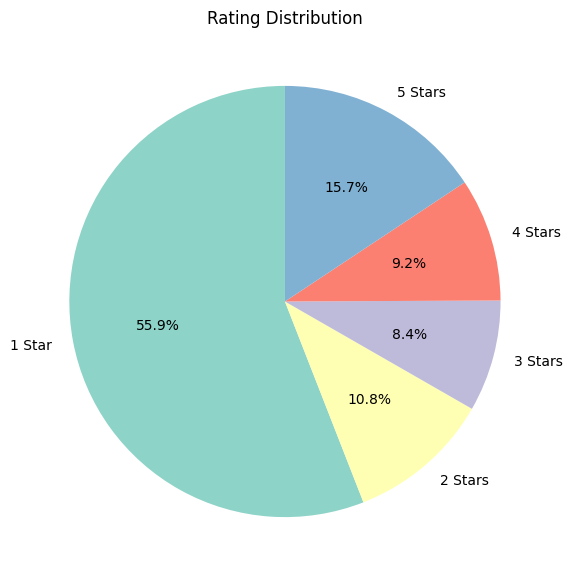

In [366]:
labels = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']

plt.figure(figsize=(7,7))

plt.pie(
    rating_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Set3.colors
)


plt.title('Rating Distribution')
plt.show()

Histogram - Review Length Distribution

In [245]:
import numpy as np

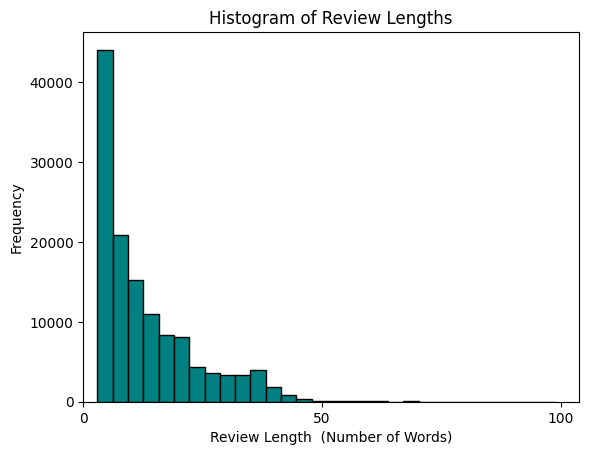

In [367]:
plt.hist(data1['word_count'], bins=30, color='teal', edgecolor='black')

plt.xlabel('Review Length  (Number of Words)')
plt.ylabel('Frequency')
plt.title('Histogram of Review Lengths')

plt.xlim(left=0)
plt.xticks(np.arange(0, data1['word_count'].max() + 50, 50))


plt.show()

BOXPLOT OF REVIEW LENGTH PER RATING

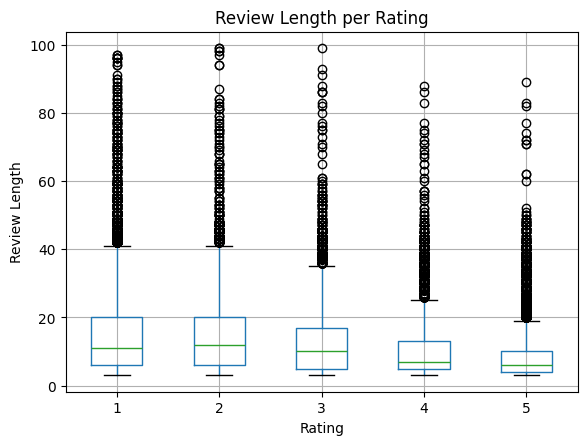

In [368]:
data1.boxplot(column='word_count', by = 'score')

plt.xlabel('Rating')
plt.ylabel('Review Length')
plt.title('Review Length per Rating')

# Remove automatic pandas subtitle
plt.suptitle('')

plt.show()

Violin Plot
Visualize density and distribution of review lengths.

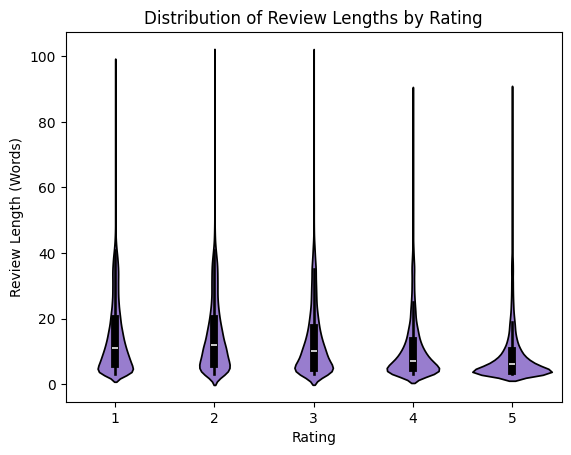

In [369]:
import seaborn as sns

sns.violinplot(
    x='score',
    y='word_count',
    data=data1,
    color='mediumpurple', edgecolor='black'
)

plt.title('Distribution of Review Lengths by Rating')
plt.xlabel('Rating')
plt.ylabel('Review Length (Words)')

plt.show()

# 11.Word Frequency Analysis
Display the most common words for each rating class.

In [249]:
from collections import Counter


In [370]:

# Top N words to display
top_n = 10

for rating in sorted(data1['score'].unique()):
    
    # Combine all reviews for the rating
    text = ' '.join(
        data1[data1['score'] == rating]['content'].astype(str)
    )
    
    # Tokenize words
    words = text.lower().split()
    
    # Remove unwanted words (like app name)
    words = [w for w in words if w != "bumble"]
    
    # Count frequencies
    word_counts = Counter(words)
    
    # Get top words
    top_words = word_counts.most_common(top_n)
    
    # Convert to DataFrame for readability
    top_words_df = pd.DataFrame(
        top_words,
        columns=['Word', 'Frequency']
    )
    
    print(f"\nTop {top_n} Words for Rating {rating}")
    print(top_words_df)


Top 10 Words for Rating 1
      Word  Frequency
0      app      51071
1     like      21151
2    match      19984
3      pay      19397
4      use      14634
5     time      13600
6    money      12603
7   people      12151
8  profile      11839
9  account      10549

Top 10 Words for Rating 2
      Word  Frequency
0      app       8866
1     like       5335
2    match       5126
3      pay       3321
4   people       3231
5      use       2747
6  profile       2503
7  message       2452
8    swipe       2451
9     time       2445

Top 10 Words for Rating 3
      Word  Frequency
0      app       6114
1     like       3655
2    match       3078
3   people       2277
4  message       1836
5      pay       1622
6     good       1601
7      use       1560
8     time       1529
9  profile       1494

Top 10 Words for Rating 4
      Word  Frequency
0      app       6282
1     like       3306
2     good       3068
3   people       2453
4    match       2068
5      use       1774
6     date  

5 Reviews per Rating

In [371]:
data1.head()

,reviewId,content,score,thumbsUpCount,at,word_count,char_count
0,a0060cfe-9e87-4694-8268-27025b9d9141,swipe swipe connection,1,0,2026-05-23 23:36:38,3,22
1,e7bdd002-fc77-4314-a4b2-6060efe53a0d,supposedly like swipe age pay premium price ri...,1,0,2026-05-23 23:27:41,18,122
4,fdaa6093-a265-4066-9a86-7a6db0915ef4,scam fake profile use opening format include i...,1,0,2026-05-23 22:23:48,15,96
6,4521430f-ec5c-4a26-a095-bfeb85cdcc7a,message long upload app freeze constantly,1,0,2026-05-23 21:03:55,6,41
7,68abfb71-cec5-4ef7-b347-0556ed7121f8,easy use app,5,0,2026-05-23 21:00:40,3,12


Displaying 5 Reviews per Rating

In [372]:
n_samples = 5

# group by rating (score) and sample reviews
sample_reviews = (
    data1.groupby("score", group_keys=False)
    .sample(n=n_samples, random_state=42)
    .reset_index(drop=True)
)

for rating in sorted(sample_reviews["score"].unique()):
    print(f"\n================ Rating: {rating} ================\n")
    
    for i, review in enumerate(sample_reviews[sample_reviews["score"] == rating]["content"], 1):
        print(f"{i}. {review}\n")


================ Rating: 1 ================

1. app update woman use long require reach allow man occasionally message lead woman likely initiative app long special unique

2. bad tinder wait like 20 hour able swipe swipe right maybe 10 people swipe trash app stick home thank covid basically force people pay premium ashamed

3. way include pay premium boost recommend app bumble

4. use day login try reset password appear error try later recognize phone number

5. mandatory pay ridiculous especially people struggle money


================ Rating: 2 ================

1. good woman creepy message woman man think date 5050 eye 70 try conversation dry date app base look difficult find look past look

2. badly app slow load load time regardless network connection open app right

3. jury bumble agree pay upgrade like paypal account debit time contact bumble await reply reimbursement money

4. notification feature additional cost

5. bad online date site ve respond look special plastic peopl

# 12 Create Balanced Dataset

Numbers of Reviews per rating

In [373]:
data1['score'].value_counts().sort_index()


score
1    72635
2    13997
3    10863
4    12003
5    20368
Name: count, dtype: int64

In [4]:
balanced_data = (
    data1.groupby("score", group_keys=False)
    .sample(n=10000, random_state=42)
    .reset_index(drop=True)
)

#shuffle dataset
balanced_data = balanced_data.sample(frac=1, random_state=42).reset_index(drop=True)

print(balanced_data["score"].value_counts().sort_index())
print(balanced_data.shape)

score
1    10000
2    10000
3    10000
4    10000
5    10000
Name: count, dtype: int64
(50000, 7)


# 13. 70:30 Stratified split

In [5]:
from sklearn.model_selection import train_test_split

X = balanced_data['content']
y = balanced_data['score']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 14. Vectorizing text - TF-IDF 

It is a method used in NLP to convert text into numbers (features) so machine learning models can understand it

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [7]:
vectorizer = TfidfVectorizer(
    max_features = 500, # Keep only the top 500 words in the dataset
    ngram_range = (1,2) #This controls how words are grouped
    
)


In [8]:
# Fit ONLY on training data

x_train_vec = vectorizer.fit_transform(X_train)

# Transform test data using same vectorizer
x_test_vec = vectorizer.transform(X_test)

In [9]:
print(x_train_vec.shape)
print(x_test_vec.shape)

(35000, 500)
(15000, 500)


In [11]:
print(y_train.value_counts(normalize=True).sort_index())

print(y_test.value_counts(normalize=True).sort_index())

score
1    0.2
2    0.2
3    0.2
4    0.2
5    0.2
Name: proportion, dtype: float64
score
1    0.2
2    0.2
3    0.2
4    0.2
5    0.2
Name: proportion, dtype: float64


In [12]:
#